In [1]:
!pip install networkx numpy scikit-learn pandas

In [3]:
import urllib.request
import zipfile
import os


# Extract
with zipfile.ZipFile("football.zip", 'r') as zip_ref:
    zip_ref.extractall("football_data")

print("Dataset downloaded and extracted!")

Dataset downloaded and extracted!


In [5]:
import networkx as nx
from scipy.io import mmread

# Load sparse matrix from .mtx file
matrix = mmread("football_data/football.mtx")

# Convert to NetworkX graph
G = nx.from_scipy_sparse_array(matrix)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 35
Edges: 118


In [6]:
import random
import numpy as np

def initialize_population(pop_size, num_nodes, num_communities):
    return [np.random.randint(0, num_communities, num_nodes) for _ in range(pop_size)]

In [7]:
from networkx.algorithms.community.quality import modularity

def calculate_modularity(G, chromosome):
    communities = {}

    for node, comm in enumerate(chromosome):
        communities.setdefault(comm, []).append(node)

    return modularity(G, list(communities.values()))

In [8]:
def selection(population, fitness_scores, k=3):
    selected = random.sample(list(zip(population, fitness_scores)), k)
    selected.sort(key=lambda x: x[1], reverse=True)
    return selected[0][0]

def crossover(parent1, parent2):
    point = random.randint(1, len(parent1)-1)
    return np.concatenate((parent1[:point], parent2[point:]))

def mutation(chromosome, num_communities, rate=0.1):
    for i in range(len(chromosome)):
        if random.random() < rate:
            chromosome[i] = random.randint(0, num_communities-1)
    return chromosome

In [9]:
def decoding(G, chromosome):
    for i in range(len(chromosome)):
        for j in set(chromosome):

            temp = chromosome.copy()
            temp[i] = j

            if calculate_modularity(G, temp) > calculate_modularity(G, chromosome):
                chromosome = temp

    return chromosome

In [10]:
import time
def genetic_algorithm(G, pop_size=20, generations=30, num_communities=5):
    start_time = time.time()
    num_nodes = G.number_of_nodes()
    population = initialize_population(pop_size, num_nodes, num_communities)
    best_solution = None
    best_fitness = -1
    for gen in range(generations):
        fitness_scores = [calculate_modularity(G, ind) for ind in population]
        new_population = []
        for _ in range(pop_size):
            p1 = selection(population, fitness_scores)
            p2 = selection(population, fitness_scores)
            child = crossover(p1, p2)
            child = mutation(child, num_communities)
            child = decoding(G, child)
            new_population.append(child)
        population = new_population
        max_fit = max(fitness_scores)
        if max_fit > best_fitness:
            best_fitness = max_fit
            best_solution = population[np.argmax(fitness_scores)]
        print(f"Generation {gen+1}, Best Modularity: {best_fitness}")

    runtime = time.time() - start_time

    return best_solution, best_fitness, runtime

In [11]:
best_solution, best_modularity, runtime = genetic_algorithm(G)

print("\nFinal Results:")
print("Best Modularity:", best_modularity)
print("Runtime:", runtime)

Generation 1, Best Modularity: 0.014122378626831375
Generation 2, Best Modularity: 0.3043780522838265
Generation 3, Best Modularity: 0.30698075265728236
Generation 4, Best Modularity: 0.34287848319448433
Generation 5, Best Modularity: 0.34287848319448433
Generation 6, Best Modularity: 0.3540304510198219
Generation 7, Best Modularity: 0.3551106004021833
Generation 8, Best Modularity: 0.36207411663315137
Generation 9, Best Modularity: 0.36207411663315137
Generation 10, Best Modularity: 0.36207411663315137
Generation 11, Best Modularity: 0.36207411663315137
Generation 12, Best Modularity: 0.36207411663315137
Generation 13, Best Modularity: 0.36207411663315137
Generation 14, Best Modularity: 0.36207411663315137
Generation 15, Best Modularity: 0.36207411663315137
Generation 16, Best Modularity: 0.36207411663315137
Generation 17, Best Modularity: 0.36207411663315137
Generation 18, Best Modularity: 0.36207411663315137
Generation 19, Best Modularity: 0.36207411663315137
Generation 20, Best Mod

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

def visualize_communities(G, labels, title="Community Detection"):

    plt.figure(figsize=(10, 8))

    # Layout
    pos = nx.spring_layout(G, seed=42)

    unique_labels = np.unique(labels)

    # Generate distinct colors using colormap
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

    # Draw nodes community-wise with different colors
    for color, label in zip(colors, unique_labels):
        node_list = [node for node in range(len(labels)) if labels[node] == label]

        nx.draw_networkx_nodes(
            G, pos,
            nodelist=node_list,
            node_color=[color],   # 👈 different color
            node_size=80,
            label=f"Community {int(label)}"
        )
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.3)

    plt.title(title)
    plt.legend(scatterpoints=1)
    plt.show()

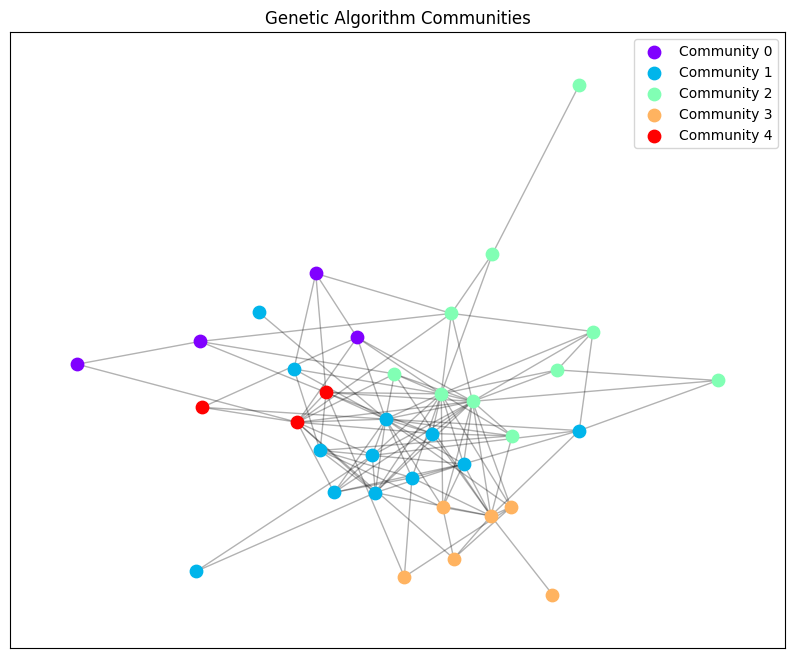

In [23]:
visualize_communities(G, best_solution, title="Genetic Algorithm Communities")